### Section 0.1 — Load dataset & build DataFrame

In [1]:
import json

records = []
with open("../out/training/epistemic_factkg_training.jsonl", "r") as f:
    for line in f:
        records.append(json.loads(line))

print(len(records))

5135


In [2]:
import pandas as pd

df = pd.DataFrame(
    [
        {
            "dataset": r["provenance"]["dataset"],
            "verdict": r["verdict"]["label"],
            "pramana": r["epistemic"]["pramana_primary"],
            "confidence_weight": r["epistemic"]["confidence_weight"],
            "num_evidence": len(r["evidence"]),
            "num_triples": len(r["claim_triples"]) if r["claim_triples"] else 0,
            "claim_len": len(r["claim"].split()),
            "evidence_text_len": sum(
                len((e["text"] or "").split()) for e in r["evidence"]
            ),
        }
        for r in records
    ]
)

df["dataset"].value_counts()

dataset
averitec    3335
ai2thor     1800
Name: count, dtype: int64

---
### Section 0.2 — Verdict distribution

Goal: check class imbalance across the 4 verdict labels, broken down by source dataset.

**If any class has <5% of total records, plan to use weighted `CrossEntropyLoss` in training.**

Hint: `seaborn.countplot(data=df, x='verdict', hue='dataset')`

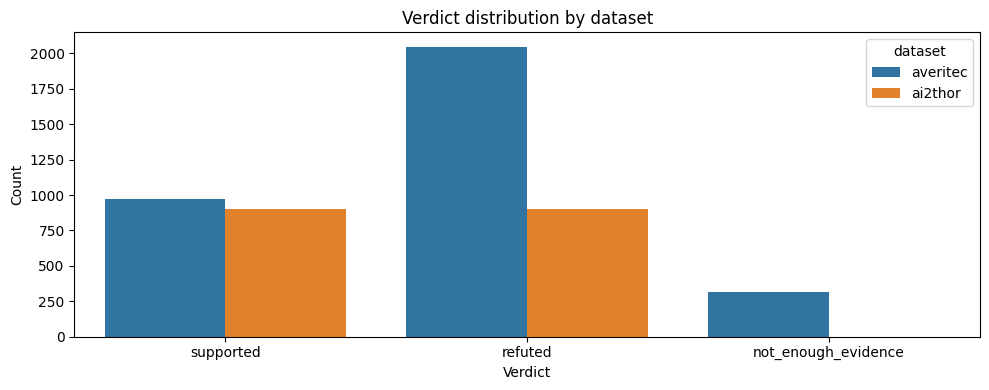

dataset   verdict            
ai2thor   refuted                 900
          supported               900
averitec  not_enough_evidence     317
          refuted                2047
          supported               971


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(data=df, x="verdict", hue="dataset", ax=ax)
ax.set_title("Verdict distribution by dataset")
ax.set_xlabel("Verdict")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(df.groupby(["dataset", "verdict"]).size().to_string())

---
### Section 0.3 — Pramana distribution

Goal: verify the controlled Pramana distribution from ADR-012 was achieved.

Expected targets: testimony ~41%, perception ~19%, non_apprehension ~13%, comparison_analogy ~11%, inference ~5.5%.

Hint: `df['pramana'].value_counts(normalize=True)` gives percentages.

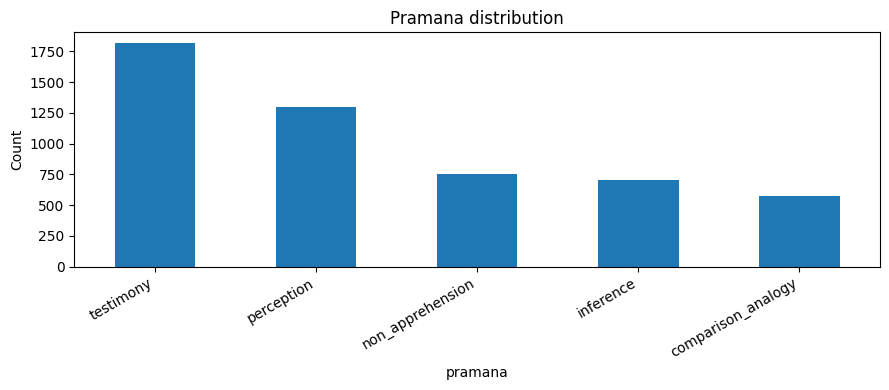

Pramana                       Count   Actual%   Target%
  testimony                    1813     35.3%       41
  perception                   1298     25.3%       19
  non_apprehension              750     14.6%       13
  inference                     704     13.7%      5.5
  comparison_analogy            570     11.1%       11


In [4]:
counts = df["pramana"].value_counts()
pct = df["pramana"].value_counts(normalize=True) * 100
targets = {
    "testimony": 41,
    "perception": 19,
    "non_apprehension": 13,
    "comparison_analogy": 11,
    "inference": 5.5,
}

fig, ax = plt.subplots(figsize=(9, 4))
counts.plot(kind="bar", ax=ax)
ax.set_title("Pramana distribution")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"{'Pramana':<28} {'Count':>6}  {'Actual%':>8}  {'Target%':>8}")
for p in counts.index:
    print(f"  {p:<26} {counts[p]:>6}  {pct[p]:>7.1f}%  {targets.get(p, '—'):>7}")

---
### Section 0.4 — Evidence cardinality

Goal: understand how many evidence items each claim has.

This determines the variable number of EvidenceNodes per subgraph — important for batching strategy.

Report: min, max, mean, median of `num_evidence`. Plot histogram by dataset.

count    5135.000000
mean        2.094060
std         1.584988
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        16.000000
Name: num_evidence, dtype: float64


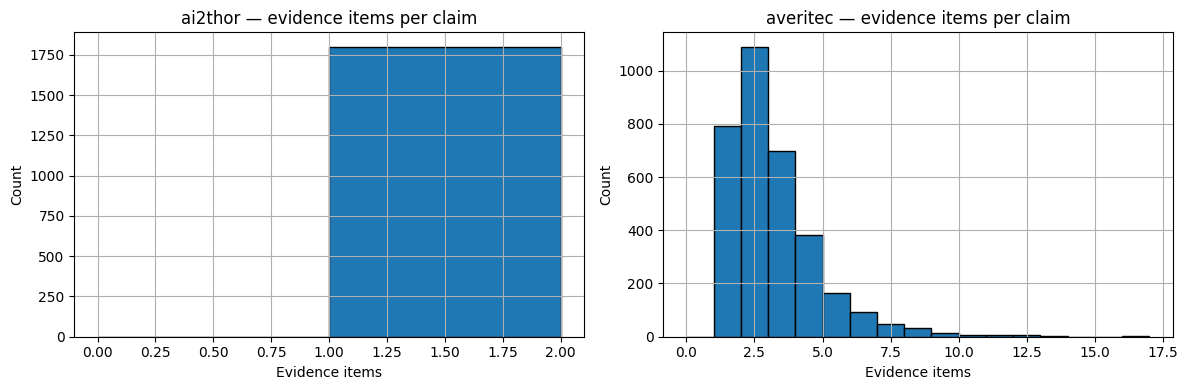

In [5]:
print(df["num_evidence"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for i, (name, g) in enumerate(df.groupby("dataset")):
    g["num_evidence"].hist(
        bins=range(0, int(g["num_evidence"].max()) + 2), ax=axes[i], edgecolor="black"
    )
    axes[i].set_title(f"{name} — evidence items per claim")
    axes[i].set_xlabel("Evidence items")
    axes[i].set_ylabel("Count")
plt.tight_layout()
plt.show()

---
### Section 0.5 — Text length analysis

Goal: find outliers in claim text and evidence text length (in words).

The sentence-transformer `all-MiniLM-L6-v2` truncates at 256 word-pieces.
Flag any claims or evidence items that are likely to be truncated (rough threshold: >200 words).

Claim text length (words):
count    5135.000000
mean       13.737098
std         8.346077
min         0.000000
25%         7.000000
50%        11.000000
75%        17.000000
max        73.000000
Name: claim_len, dtype: float64

Records with claim_len > 200 words: 0


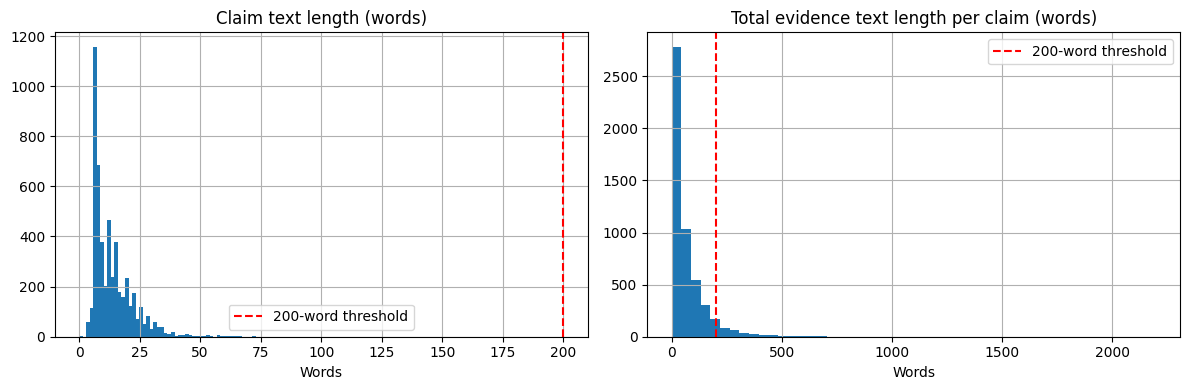

In [6]:
print("Claim text length (words):")
print(df["claim_len"].describe())
print(f"\nRecords with claim_len > 200 words: {(df['claim_len'] > 200).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["claim_len"].hist(bins=50, ax=axes[0])
axes[0].axvline(200, color="red", linestyle="--", label="200-word threshold")
axes[0].set_title("Claim text length (words)")
axes[0].set_xlabel("Words")
axes[0].legend()

df["evidence_text_len"].hist(bins=50, ax=axes[1])
axes[1].axvline(200, color="red", linestyle="--", label="200-word threshold")
axes[1].set_title("Total evidence text length per claim (words)")
axes[1].set_xlabel("Words")
axes[1].legend()
plt.tight_layout()
plt.show()

---
### Section 0.6 — Triple density (AI2THOR only)

Goal: understand how many claim triples each AI2THOR record has.

This determines the number of TripleNodes per AI2THOR subgraph.
AVeriTeC records will all have `num_triples == 0` — filter them out for this section.

AI2THOR records: 1800
count    1800.000000
mean        0.222222
std         0.533018
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         2.000000
Name: num_triples, dtype: float64


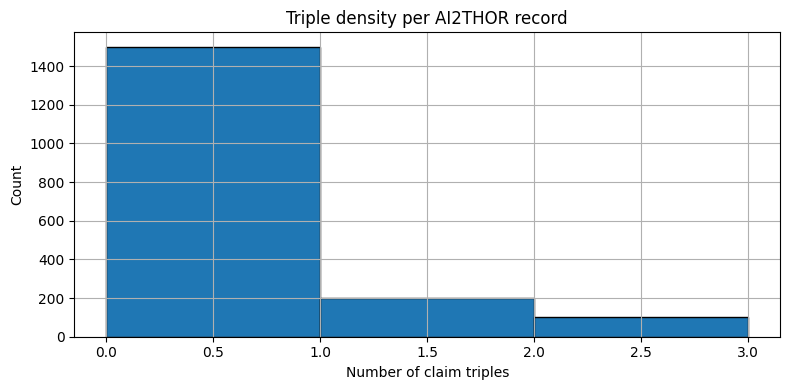

In [7]:
ai2thor_df = df[df["dataset"] == "ai2thor"]
print(f"AI2THOR records: {len(ai2thor_df)}")
print(ai2thor_df["num_triples"].describe())

fig, ax = plt.subplots(figsize=(8, 4))
ai2thor_df["num_triples"].hist(
    bins=range(0, int(ai2thor_df["num_triples"].max()) + 2), ax=ax, edgecolor="black"
)
ax.set_title("Triple density per AI2THOR record")
ax.set_xlabel("Number of claim triples")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

---
### Section 0.7 — Confidence weight distribution per Pramana type

Goal: confirm that confidence weights separate cleanly by Pramana type.

Expected order (descending): perception > testimony > non_apprehension > comparison_analogy > inference.

Hint: `sns.boxplot(data=df, x='pramana', y='confidence_weight')`

If weights do NOT separate by type, there is a bug in the converter.

                     count      mean       std   min   25%   50%     75%  \
pramana                                                                    
comparison_analogy   570.0  0.941200  0.039499  0.65  0.93  0.93  0.9685   
inference            704.0  0.910000  0.000000  0.91  0.91  0.91  0.9100   
non_apprehension     750.0  0.750000  0.000000  0.75  0.75  0.75  0.7500   
perception          1298.0  0.956456  0.015479  0.95  0.95  0.95  0.9500   
testimony           1813.0  0.800000  0.000000  0.80  0.80  0.80  0.8000   

                       max  
pramana                     
comparison_analogy  0.9685  
inference           0.9100  
non_apprehension    0.7500  
perception          0.9984  
testimony           0.8000  


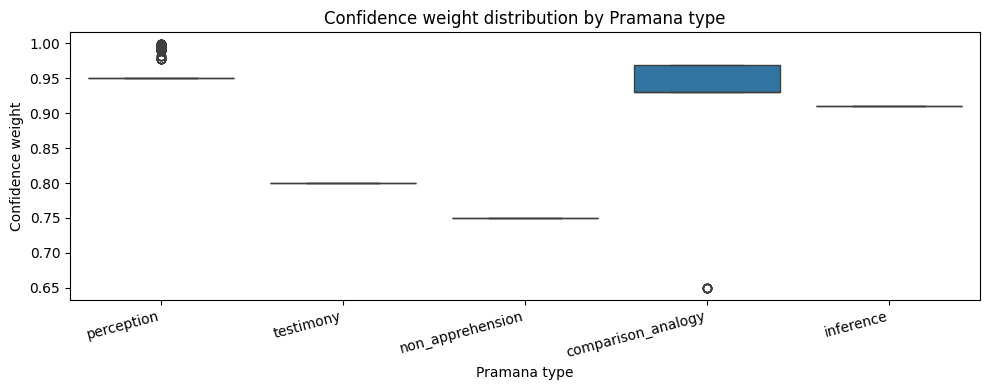

In [8]:
print(df.groupby("pramana")["confidence_weight"].describe())

pramana_order = [
    "perception",
    "testimony",
    "non_apprehension",
    "comparison_analogy",
    "inference",
]
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x="pramana", y="confidence_weight", order=pramana_order, ax=ax)
ax.set_title("Confidence weight distribution by Pramana type")
ax.set_xlabel("Pramana type")
ax.set_ylabel("Confidence weight")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

---
### Section 0.8 — Source × verdict heatmap

Goal: spot if one source dataset dominates a specific verdict class.

For example, if `not_enough_evidence` appears only in AVeriTeC and never in AI2THOR, 
the model may learn to use source identity as a shortcut instead of reasoning.

Hint: `pd.crosstab(df['dataset'], df['verdict'])` then `sns.heatmap(..., annot=True, fmt='d')`

verdict   not_enough_evidence  refuted  supported
dataset                                          
ai2thor                     0      900        900
averitec                  317     2047        971

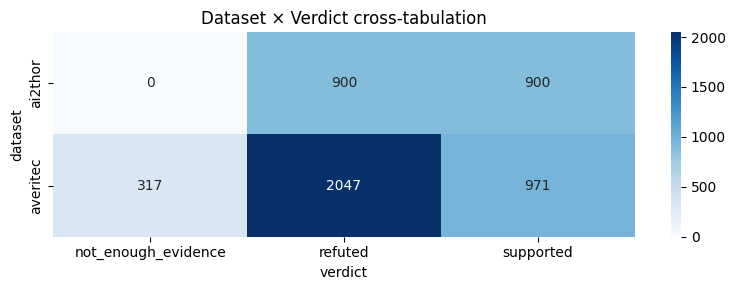

In [9]:
ct = pd.crosstab(df["dataset"], df["verdict"])
print(ct)

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Dataset × Verdict cross-tabulation")
plt.tight_layout()
plt.show()

---
### Section 0.9 — Graph size estimate

Goal: estimate the average number of nodes and edges per subgraph under the proposed schema.

For each record, compute:
- **nodes** = 1 (claim) + num_evidence + 1 (epistemic) + num_triples
- **edges** = num_evidence×2 (has_evidence + supports, bidirectional) + 1 (has_epistemic) + num_triples×2 (has_triple + from_triple, AI2THOR only)

Report mean nodes, mean edges, and estimated total memory at float32 (nodes × 384 × 4 bytes).

In [10]:
# nodes = 1 (claim) + num_evidence + 1 (epistemic) + num_triples
# edges = num_evidence (has_evidence) + num_evidence (stance reverse)
#       + 1 (has_epistemic) + num_triples (has_triple) + num_triples (from_triple)
df["estimated_nodes"] = 1 + df["num_evidence"] + 1 + df["num_triples"]
df["estimated_edges"] = (
    df["num_evidence"]  # has_evidence
    + df["num_evidence"]  # supports / refutes / absent (one per evidence)
    + 1  # has_epistemic
    + df["num_triples"]  # has_triple (AI2THOR only)
    + df["num_triples"]  # from_triple (AI2THOR only)
)

print(f"Mean nodes per subgraph  : {df['estimated_nodes'].mean():.1f}")
print(f"Mean edges per subgraph  : {df['estimated_edges'].mean():.1f}")
print(f"Max nodes                : {df['estimated_nodes'].max()}")
print(f"Max edges                : {df['estimated_edges'].max()}")

total_nodes = df["estimated_nodes"].sum()
mem_mb = total_nodes * 384 * 4 / 1e6
print(f"\nTotal nodes (all records): {total_nodes:,}")
print(f"Estimated memory (float32, 384-d): {mem_mb:.1f} MB")

Mean nodes per subgraph  : 4.2
Mean edges per subgraph  : 5.3
Max nodes                : 18
Max edges                : 33

Total nodes (all records): 21,423
Estimated memory (float32, 384-d): 32.9 MB


---
### Checkpoint — EDA summary

Write your 3–5 key observations here before moving to section 1 (dependencies).

Example format:
- testimony dominates at X%
- `not_enough_evidence` appears only in AVeriTeC → model may need dataset feature or class weight
- avg X evidence items per claim → variable-size graphs, use PyG DataLoader
- avg X nodes per subgraph → estimated Y MB total
- ...

**EDA Checkpoint — Key Observations**

**1. Verdict imbalance requires weighted loss (confirmed).**  
`refuted` dominates at 57.4%, `supported` 36.4%, `not_enough_evidence` (NEE) 6.2%.  
Inverse-frequency class weights applied: `[supported=0.91, refuted=0.58, NEE=5.40]`.  
Random 3-class baseline = 33.3%; model target >50% after 10 epochs.

**2. NEE is exclusive to AVeriTeC — source-identity shortcut risk.**  
`not_enough_evidence` appears in AVeriTeC only (317 records, 0 in AI2THOR).  
AI2THOR is perfectly balanced: 900 supported / 900 refuted.  
AVeriTeC is refuted-heavy: 2,047 refuted vs 971 supported.  
→ Do NOT include `provenance.dataset` as a model feature. Monitor per-source accuracy in Phase 6.

**3. Pramana distribution deviates from ADR-012 targets.**  
`perception` is above target (25.3% vs 19%), `inference` is well above target (13.7% vs 5.5%).  
`testimony` is below target (35.3% vs 41%).  
No re-balancing before training — per-Pramana accuracy breakdown in Phase 6 will capture any bias.

**4. Evidence cardinality is highly right-skewed — variable-size graphs, no padding needed.**  
Mean = 2.1 evidence items, median = 1, max = 16. PyG DataLoader handles this via disjoint union batching.  
Mean subgraph size = 4.2 nodes, 5.3 edges. Max = 18 nodes / 33 edges.  
→ 2-layer GNN confirmed safe: no over-smoothing risk on these small subgraphs.

**5. Text lengths are well within the embedding model limit.**  
All claim texts ≤73 words (0 exceed 200-word threshold). 359 records (7%) have total evidence text >200 words — minor truncation risk in per-evidence embeddings, acceptable for Phase 4 baseline.

**6. Triple nodes are sparse — AI2THOR rarely uses claim triples.**  
Mean 0.22 triples per AI2THOR record; most records have 0, max is 2.  
TripleNodes exist in a minority of subgraphs. Empty `edge_index = [2,0]` ensured for all graphs for PyG slice consistency.

**7. Confidence weights correctly separate by Pramana type (converter validated).**  
`perception=0.956 > comparison_analogy=0.941 > inference=0.910 > testimony=0.800 > non_apprehension=0.750`.  
Weights are deterministic constants (no spread within type). The `has_epistemic` edge_attr encodes these directly into the GAT attention scaling in Phase 4.

**8. Dataset fits comfortably in RAM.**  
Total ~21,423 nodes × 384-d float32 = **32.9 MB** — well within `InMemoryDataset` limit. Embedding cache reused on subsequent builds.